In [97]:
import uproot
import pandas as pd
import numpy as np
import glob


In [98]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [99]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_etaetapip_loose_v7_250122_temp"
cm_elements = ["etahp_13_had_4S_off_v1", "etahp_13_had_4S_v3", "etahp_23_had_4S_off_v1", "etahp_23_had_4S_v1", "etahp_23_had_5Sscan_10657_v1", "etahp_23_had_5Sscan_10706_v1",\
               "etahp_23_had_5Sscan_10751_v1", "etahp_23_had_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_gg_K"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [100]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [101]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,17252.000000,17252.000000,17252.000000,17252.000000,17252.000000
mean,1.673363,0.324635,0.555612,1.582717,0.013564
std,0.144897,0.440479,0.408102,0.751889,0.999937
min,1.500065,-0.973055,-0.866847,0.417627,-1.000000
25%,1.578762,0.014749,0.335448,0.971414,-1.000000
50%,1.634127,0.431913,0.705514,1.451816,1.000000
75%,1.719866,0.685463,0.881152,2.039995,1.000000
max,2.099845,0.998722,0.968485,4.904402,1.000000


In [102]:
df_proc13 = df_proc13.query('Dp_M> 1.73 & Dp_M<2.1')


In [103]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,4077.000000,4077.000000,4077.000000,4077.000000,4077.000000
mean,1.886176,0.355575,0.617969,1.604789,0.009075
std,0.138704,0.440048,0.399319,0.805301,1.000081
min,1.730052,-0.973055,-0.862539,0.417627,-1.000000
25%,1.771363,0.064121,0.484397,0.917002,-1.000000
50%,1.810235,0.456976,0.783674,1.497179,1.000000
75%,2.048846,0.709162,0.911156,2.108702,1.000000
max,2.099845,0.997492,0.968485,4.891529,1.000000


In [104]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [105]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_241213_temp"
cm_elements = ["15rd_eta_e7_18_4S_v3", "15rd_eta_e20_b26_v1", "15rd_eta_e20_e26_4S_v2", "15rd_eta_e21_5S_scan_v1", "15rd_eta_mori_off_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_gg_K"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [106]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


In [107]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,52106.000000,52106.000000,52106.000000,52106.000000,52106.000000
mean,1.783944,0.309126,0.552709,1.657402,-0.002764
std,0.171597,0.430222,0.406185,0.751938,1.000006
min,1.500002,-0.981440,-0.867804,0.405879,-1.000000
25%,1.628509,0.010413,0.323715,1.071698,-1.000000
50%,1.782548,0.407040,0.696802,1.529677,-1.000000
75%,1.956273,0.657484,0.881414,2.109742,1.000000
max,2.099997,0.999411,0.969874,4.791945,1.000000


In [108]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.73 & Dp_M<2.1')


In [109]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,29160.000000,29160.000000,29160.000000,29160.000000,29160.000000
mean,1.918175,0.302715,0.557191,1.649352,-0.006379
std,0.092578,0.435858,0.415053,0.753279,0.999997
min,1.730030,-0.981440,-0.867804,0.405879,-1.000000
25%,1.848839,-0.000594,0.323482,1.071328,-1.000000
50%,1.944397,0.392788,0.711789,1.531755,-1.000000
75%,1.975585,0.656971,0.890514,2.095726,1.000000
max,2.099997,0.999411,0.969874,4.791945,1.000000


In [110]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [111]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity, plot_error_hist


In [112]:
tree_to_compare = tree_name
plt.rcParams['font.family'] = 'DejaVu Sans'


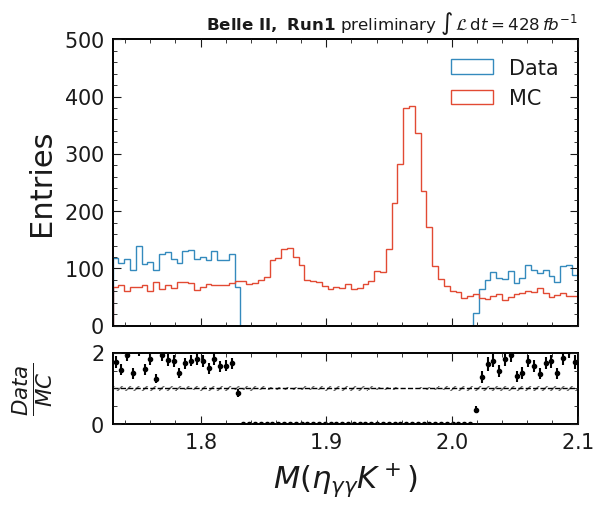

In [113]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{\gamma\gamma} K^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.73,2.1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)

# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")
# ax_main.legend()

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}.png", bbox_inches="tight")

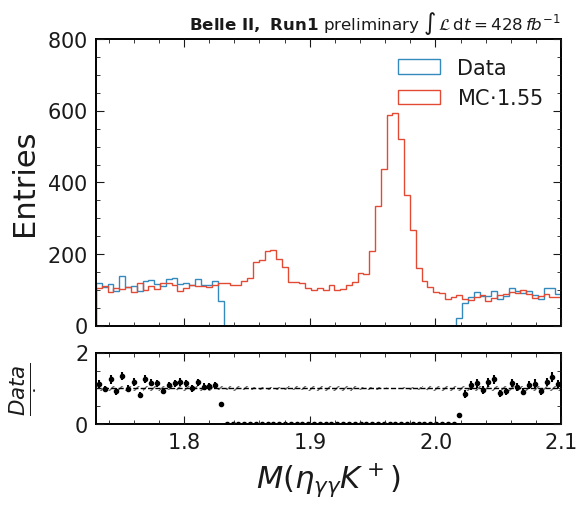

In [114]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{\gamma\gamma} K^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.73,2.1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=(1/4)*1.55)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label=r"MC$\cdot$1.55",
    comparison="split_ratio",
)

# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")
# ax_main.legend()

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}_MC_155percent.png", bbox_inches="tight")